## Quest 3
#### 1. Transformer와 비교해 변경이 필요한 부분을 서술
 - Encoder를 제거한 Decoder-Only 구조로 변경
 - Masked Self-Attention만 사용 (즉, Encoder의 Self-Attention과 Decoder의 Cross-Attention은 사용하지 않음)
 - sin/cos positional encoding을 learnable positional embedding으로 변경
 - 기존 seq2seq Transformer와 GPT-1의 구조 차이를 텍스트 블록과 코드 주석으로 설명
#### 2. 모델의 입력형태에 맞게 전처리 수행여부
 - GPT-1은 생성형 Decoder Language Model이므로,
 - 기존 챗봇의 질문-답변 쌍 seq2seq 입력이 아니라 하나의 연속 토큰 시퀀스로 다루도록 전처리를 변경
 - 예)
 -  <bos> 질문 <sep> 답변 <eos>
 - 학습 시에는 입력 시퀀스와 한 칸 오른쪽으로 shift된 target 시퀀스를 사용하여 다음 토큰 예측 방식으로 구성
#### 3. 모델의 입력 블럭을 GPT 논문 기반으로 수정
 - GPT 논문에 따라 입력을 token embedding + position embedding의 합으로 구성
 - delimiter token(예: <sep> 또는 $)도 일반 토큰처럼 임베딩을 학습
 - <bos>, <eos>와 같은 특수 토큰도 함께 학습

#### 4. GPT 모델을 정상적을 구성 여부(print(model), 러닝커브제출)
- print(model) 또는 모델 출력 구조를 통해 decoder-only GPT 구조임을 확인 가능하도록 제시
  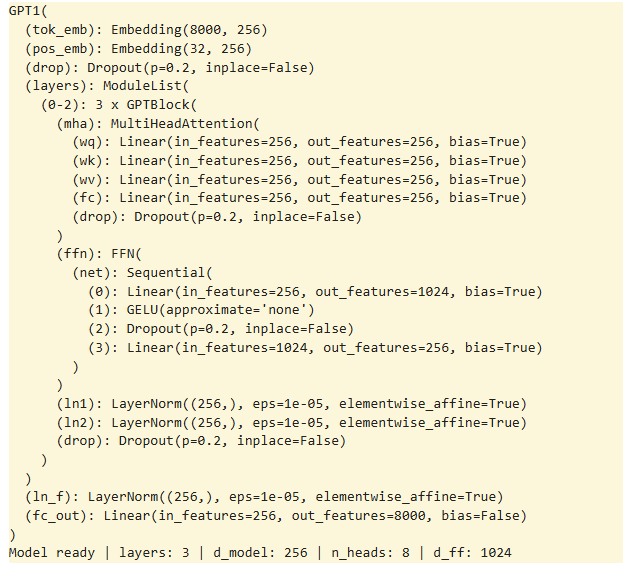
- 평가지표로 loss, perplexity, token-level accuracy 
#### 5. 입력에 따른 출력 생성
- 입력을 넣으면 다음 토큰 logits 또는 자동 생성 결과가 출력되도록 구현
- 예)
- 입력: <bos> 오늘 너무 기분 좋아 <sep>
- 출력: 무슨 일이 있었는지 이야기해볼래? <eos>

## Quest 진행방향
- 기존 Chatbot02 프로젝트 프로세스을 골격으로 GPT-1에 해당되는 부분을 수정함.
- 즉 step 0. ~ step 4.는 그대로 유지
- step 5, 6, 7은 GPT-1 논문에 맞추 조정함
### Project Process
- step 0. 라이브러리 및 기본 설정
- step 1. 데이터 다운로드
- step 2. 데이터 정제
- step 3. 데이터 토큰화
- step 4. 데이터 증강
- step 5. GPT-1 개발을 위한 데이터 재구성
- step 6. GPT-1 모델 구성
- step 7. GPT-1 평가지표
- step 8. 추가학습 및 평가
### 회고
- 앞에서 1차 학습으로 Epoch 30, 추가학습으로 Epoch 100을 돌렸으나 Underfitting 상황이다.
- 이에 재시작(Restart)하여 다시 실험을 시작한다. 이번 실험은 1차학습으로 epoch 100, 추가학습으로 100 epoch를 진행하였으나
- 두 번 모두 과소적합된 상태이다.
  Epoch 100 | train_loss=2.4786 | train_ppl=11.92 | train_acc=0.5128 || val_loss=2.2113 | val_ppl=9.13 | val_acc=0.6267 || lr=0.000200
✅ Best model restored | best_val=2.2113 | best_epoch=10
[STEP8] Epoch 100 | train_loss=2.0421 | train_ppl=7.71 | train_acc=0.5814 || val_loss=1.9430 | val_ppl=6.98 | val_acc=0.6846 || lr=0.000010
✅ STEP 8 best model restored | best_val=1.9430 | best_epoch=10
0
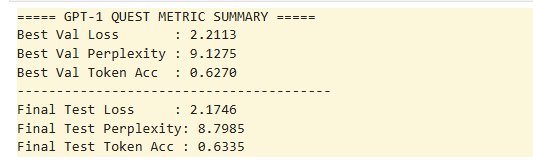
- 앞으로 레이어를 6 이상으로 늘리고, epoch도 500 이상으로 대폭 상향하여 추가학습할 예정이다.
- 이번에도 동료들에게 많이 배웠습니다. 태민님에게 layer를 늘리는 아이디어를 진규님에게 전반적 진행방향에 대한 아이디어를 공유한 것이 큰 도움이 되었습니다.- 

### step 0 라이브러리 및 기본 설정

In [1]:
# 캐시 삭제
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

print("CUDA cache cleared")

CUDA cache cleared


In [3]:
# ============================================================
# [STEP 0 - CELL 1] Imports & Global Config
# ============================================================

import numpy as np
import pandas as pd
import torch
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
from konlpy.tag import Mecab
import gensim

import re
import os
import random
import math

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(torch.__version__)

# 재현성
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", device)

# # 최대 길이 (토큰 기준) - 뒤에서 다시 조정함
MAX_LEN = 40 

# Special tokens (이전 노트북의 SPM id 관례(0~3)와 맞추기 위해 이렇게 둡니다)
PAD_TOKEN = "<pad>"
BOS_TOKEN = "<start>"
EOS_TOKEN = "<end>"
UNK_TOKEN = "<unk>"
# 구분자 추가

PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
UNK_ID = 3
# 구분자 id 추가할 예정임

2.8.0+cu126
DEVICE: cuda


### Step 1. 데이터 다운로드
- 압축해제 → questions, answers

In [6]:
# ============================================================
# [STEP 1 - CELL 1] Unzip Chatbot_data.zip
# ============================================================

import zipfile
from pathlib import Path

zip_path = Path(r"D:\PyProject\AIFFEL_AI\LLM\NLP\NLP02\data\Chatbot_data.zip")
extract_dir = zip_path.parent / "Chatbot_data_unzipped"
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

print("Extracted to:", extract_dir)

Extracted to: D:\PyProject\AIFFEL_AI\LLM\NLP\NLP02\data\Chatbot_data_unzipped


In [8]:
# ============================================================
# [STEP 1 - CELL 2] Load ChatbotData.csv -> questions, answers
# ============================================================

# 보통 파일명이 ChatbotData.csv 인 경우가 많습니다(프로젝트 표준).
# 혹시 이름이 다르면 extract_dir 아래 CSV를 자동 탐색합니다.

csv_files = list(extract_dir.rglob("*.csv"))
assert len(csv_files) > 0, f"CSV 파일을 찾지 못했습니다: {extract_dir}"

csv_path = csv_files[0]
print("Using CSV:", csv_path)

df = pd.read_csv(csv_path)
print(df.head())
print(df.columns)

# 일반적으로 Q/A 컬럼이 존재합니다.
# (예외 대비) 컬럼명이 다르면 아래 후보에서 찾습니다.
q_col_candidates = ["Q", "question", "questions", "Question"]
a_col_candidates = ["A", "answer", "answers", "Answer"]

q_col = next((c for c in q_col_candidates if c in df.columns), None)
a_col = next((c for c in a_col_candidates if c in df.columns), None)

assert q_col is not None, f"질문 컬럼을 찾지 못했습니다. columns={df.columns.tolist()}"
assert a_col is not None, f"답변 컬럼을 찾지 못했습니다. columns={df.columns.tolist()}"

questions = df[q_col].astype(str).tolist()
answers   = df[a_col].astype(str).tolist()

print("questions:", len(questions), "| answers:", len(answers))
print("Q sample:", questions[0])
print("A sample:", answers[0])

Using CSV: D:\PyProject\AIFFEL_AI\LLM\NLP\NLP02\data\Chatbot_data_unzipped\Chatbot_data-master\ChatbotData.csv
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0
Index(['Q', 'A', 'label'], dtype='str')
questions: 11823 | answers: 11823
Q sample: 12시 땡!
A sample: 하루가 또 가네요.


### Step 2. 데이터 정제 
- preprocess_sentence() 구현
- 영어는 소문자로, 영문/한글/숫자/주요 특수문자만 남기고 나머지 제거
- 특수문자 범위는 과하게 넓히지 않고, 대화에서 흔한 것 위주로 구성

In [11]:
# ============================================================
# [STEP 2 - CELL 1] preprocess_sentence()  (이전 노트북 이름 유지)
# ============================================================

def preprocess_sentence(sentence: str) -> str:
    """
    - 영문자는 소문자로 변환
    - 영문/한글/숫자/주요 특수문자만 허용, 나머지는 제거
    - 토크나이저가 문장부호 처리 가능하므로 문장부호 양옆 공백 추가 등은 생략
    """
    s = str(sentence).lower().strip()

    # 허용: 한글, 영문, 숫자, 공백, 그리고 주요 특수문자(대화 데이터에 흔한 것)
    # . , ? ! ~ % @ # & ( ) [ ] { } : ; ' " - _ + = / \ |
    s = re.sub(r"[^0-9a-zA-Z가-힣\s\.\,\?\!\~\%\@\#\&\(\)\[\]\{\}\:\;\'\"\-\_\+\=\/\\\|]", "", s)

    # 공백 정리
    s = re.sub(r"\s+", " ", s).strip()
    return s

print(preprocess_sentence("안녕?? HELLO@@@ 😊 ㅎㅎㅎ"))

안녕?? hello@@@


### Step 3. 데이터 토큰화
#### 3.1 Tokenizer getter(Mecab -> Okt fallback)
- build_corpus() + Windows Mecab 대처
- KoNLPy 문서에서 konlpy.tag.Mecab()은 Windows 미지원
- 대처 옵션: (권장) WSL2(우분투)에서 KoNLPy Mecab 사용
- Windows 네이티브에서 mecab-ko-msvc 설치(다만 KoNLPy Mecab이 “공식 지원”은 아니라서 환경마다 편차가 있음)
- 당장 진행이 목표면 Okt().morphs로 fallback(성능은 Mecab이 더 좋을 때가 많지만 파이프라인은 돌아감)
- 아래 코드는 가능하면 Mecab, 실패하면 Okt로 전환

In [14]:
# ============================================================
# [STEP 3 - CELL 1] Tokenizer getter (Mecab -> Okt fallback)
# ============================================================

def get_morphs():
    """
    반환값: callable(str) -> List[str]
    우선순위:
      1) KoNLPy Mecab (WSL/리눅스 환경에서 주로 성공)  :contentReference[oaicite:5]{index=5}
      2) KoNLPy Okt fallback
    """
    try:
        from konlpy.tag import Mecab
        mecab = Mecab()  # Windows에선 일반적으로 여기서 실패 가능 :contentReference[oaicite:6]{index=6}
        print("Tokenizer: KoNLPy Mecab")
        return mecab.morphs
    except Exception as e:
        print("KoNLPy Mecab 사용 불가 -> Okt로 대체합니다.")
        print("원인(참고):", repr(e))
        from konlpy.tag import Okt
        okt = Okt()
        print("Tokenizer: KoNLPy Okt")
        return okt.morphs

morphs = get_morphs()
print(morphs("지루하다 놀러가고 싶어"))

KoNLPy Mecab 사용 불가 -> Okt로 대체합니다.
원인(참고): Exception('The MeCab dictionary does not exist at "/usr/local/lib/mecab/dic/mecab-ko-dic". Is the dictionary correctly installed?\nYou can also try entering the dictionary path when initializing the Mecab class: "Mecab(\'/some/dic/path\')"')
Tokenizer: KoNLPy Okt
['지루하다', '놀러', '가고', '싶어']


#### 3.2 build_corpus() 구현 + 기존 make_corpus() 이름 유지
- src/tgt 각각 정제+토큰화
- 길이 제한 초과 제거
- 중복 제거(소스는 소스대로, 타겟은 타겟대로)
- 쌍이 흐트러지지 않게 동일 인덱스를 유지하며 필터링
#### ✅ 구현 방식:
- 소스/타겟 각각 “허용 여부(keep mask)”를 만들고, 둘 다 keep인 것만 남김
- 중복 체크는 각각 seen_src, seen_tgt로 관리

In [17]:
# ============================================================
# [STEP 3 - CELL 2] make_corpus() 이름 유지
# ============================================================

def make_corpus(src_sentences, tgt_sentences, tokenizer_func, max_len=40):
    """
    반환: (src_corpus, tgt_corpus)
    - src/tgt 각각 preprocess_sentence 후 tokenizer_func 적용
    - 토큰 길이 >= max_len 인 문장 제외 (요구사항: 일정 길이 이상 제외)
    - 중복 문장 제외 (src는 src대로, tgt는 tgt대로)
    - 쌍이 흐트러지지 않도록 keep mask를 적용
    """
    assert len(src_sentences) == len(tgt_sentences)

    src_corpus = []
    tgt_corpus = []

    seen_src = set()
    seen_tgt = set()

    for s, t in zip(src_sentences, tgt_sentences):
        s_clean = preprocess_sentence(s)
        t_clean = preprocess_sentence(t)

        s_tokens = tokenizer_func(s_clean)
        t_tokens = tokenizer_func(t_clean)

        # 길이 제한 (>= max_len 제외)
        if len(s_tokens) >= max_len or len(t_tokens) >= max_len:
            continue

        # 중복 제거 (각각 따로)
        s_key = " ".join(s_tokens)
        t_key = " ".join(t_tokens)

        if s_key in seen_src:
            continue
        if t_key in seen_tgt:
            continue

        seen_src.add(s_key)
        seen_tgt.add(t_key)

        src_corpus.append(s_tokens)
        tgt_corpus.append(t_tokens)

    return src_corpus, tgt_corpus

In [19]:
# ============================================================
# [STEP 3 - CELL 3] build_corpus() (프로젝트 요구 이름 추가 제공)
# - 내부적으로 make_corpus를 호출하여 "기존 이름 유지" + "과제 요구 충족"
# ============================================================

def build_corpus(src_sentences, tgt_sentences, tokenize_func, max_len=40):
    return make_corpus(src_sentences, tgt_sentences, tokenize_func, max_len=max_len)

que_corpus, ans_corpus = build_corpus(questions, answers, morphs, max_len=MAX_LEN)

print("que_corpus:", len(que_corpus), "ans_corpus:", len(ans_corpus))
print("Q tokens sample:", que_corpus[0])
print("A tokens sample:", ans_corpus[0])

que_corpus: 7701 ans_corpus: 7701
Q tokens sample: ['12시', '땡', '!']
A tokens sample: ['하루', '가', '또', '가네요', '.']


### Step 4. Augmentation — Word2Vec + lexical_sub()
- Kyubyong/wordvectors에서 Korean(w) Word2Vec를 받아 ko.bin 확보
- gensim으로 로드해서 lexical substitution 적용
- !pip install gensim

In [21]:
# ============================================================
# [STEP 4 - CELL 1] Load or Train Word2Vec + Safe Sample Check
# - 변수명/흐름: (que_corpus, ans_corpus, SEED) 기준 유지
# - 김진규님 방식 추가: (1) KeyedVectors 로드 옵션, (2) 안전 샘플 체크
# ============================================================
# pip install gensim tqdm  (안 되어 있으면 설치)

import os
import random
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

# Step3에서 생성된 토큰 코퍼스 사용
sentences = que_corpus + ans_corpus

# (선택) 사전학습 KeyedVectors(.bin) 경로가 있으면 우선 로드
# - 동료의 ko_converted.bin을 그대로 쓰고 싶으면 아래 경로만 맞추세요.
PRETRAINED_BIN = "ko_converted.bin"  # 예: r"D:\PyProject\...\ko_converted.bin" 로 바꿔도 됨
USE_PRETRAINED = os.path.exists(PRETRAINED_BIN)

if USE_PRETRAINED:
    wv = KeyedVectors.load_word2vec_format(PRETRAINED_BIN, binary=True)
    print("✅ Pretrained KeyedVectors loaded:", PRETRAINED_BIN)
    print("vocab size:", len(wv))
else:
    # 로컬 Word2Vec 학습 (과제용 빠른 세팅) - 선생님 코드 유지
    w2v_model = Word2Vec(
        sentences=sentences,
        vector_size=200,
        window=5,
        min_count=1,   # ✅ 1로 설정 (vocab 누락 방지)
        workers=4,
        sg=1,          # skip-gram
        epochs=20,
        seed=SEED
    )
    wv = w2v_model.wv
    print("✅ Local Word2Vec trained.")
    print("vocab size:", len(wv.key_to_index))

# --- 안전한 sample similar 출력 ---
if sentences and len(sentences[0]) > 0:
    tok0 = sentences[0][0]
    if tok0 in wv:
        print("sample similar:", tok0, "=>", wv.most_similar(tok0, topn=5))
    else:
        any_tok = next(iter(wv.key_to_index.keys())) if hasattr(wv, "key_to_index") else next(iter(wv.index_to_key))
        print("sample similar:", any_tok, "=>", wv.most_similar(any_tok, topn=5))
else:
    print("No valid tokens for sample check.")

✅ Local Word2Vec trained.
vocab size: 11410
sample similar: 12시 => [('입어보는', 0.982317328453064), ('비행기', 0.9810588955879211), ('예비', 0.9807586073875427), ('기우제', 0.9806386232376099), ('계', 0.9799591302871704)]


In [22]:
# ============================================================
# [STEP 4 - CELL 2] lexical_sub() (이전 노트북 이름 유지)
# - 기존 방식(확률적 치환 + topn 랜덤) + 강진규님 방식(문장당 1토큰 치환 시도) 결합
# ============================================================

def lexical_sub(tokens, wv_model, replace_prob=0.3, topn=10, max_replacements=1, special_tokens=None):
    """
    tokens: List[str]
    - 문장 내 토큰을 유사어로 치환하는 증강
    - 안전 장치:
      1) wv에 존재하는 토큰만 후보
      2) special token 제외
      3) 기본적으로 문장당 max_replacements=1개만 치환(동료 방식의 안정성)
      4) 유사어 후보(topn) 중 랜덤 선택(선생님 방식의 다양성)
    """
    if tokens is None or len(tokens) == 0:
        return None

    if special_tokens is None:
        special_tokens = set()
    else:
        special_tokens = set(special_tokens)

    # 치환 가능한 토큰 인덱스 수집
    valid_idx = []
    for i, tok in enumerate(tokens):
        if tok in special_tokens:
            continue
        if tok in wv_model:
            valid_idx.append(i)

    if not valid_idx:
        return None

    new_tokens = tokens[:]
    replacements = 0

    # 무작위 순서로 돌면서 replace_prob에 따라 치환
    random.shuffle(valid_idx)
    for i in valid_idx:
        if replacements >= max_replacements:
            break
        if random.random() > replace_prob:
            continue

        tok = new_tokens[i]
        try:
            sims = wv_model.most_similar(tok, topn=topn)
        except Exception:
            continue

        cand = [w for (w, score) in sims if w != tok and (w not in special_tokens)]
        if not cand:
            continue

        new_tokens[i] = random.choice(cand)
        replacements += 1

    # 실제로 바뀐 게 없으면 None 처리(동료 방식: 증강 실패는 추가하지 않음)
    if new_tokens == tokens:
        return None

    return new_tokens


# quick test
print("Q[0]:", que_corpus[0])
print("Q[0] aug:", lexical_sub(que_corpus[0], wv, replace_prob=0.5, topn=10, max_replacements=1,
                              special_tokens=[PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN]))


Q[0]: ['12시', '땡', '!']
Q[0] aug: ['12시', '깎아요', '!']


In [23]:
# ============================================================
# [STEP 4 - CELL 3] Build augmented dataset (가변 증강 + 2회 시도)
# - 기본: 원본은 항상 포함
# - 추가:
#   1) (augQ1, oriA)
#   2) (oriQ, augA1)
#   3) (augQ1, augA1)
#   4) 2회차 증강(augQ2 / augA2)이 1회차와 다르면 추가
# ============================================================

from tqdm import tqdm  # ✅ notebook 말고 기본 tqdm 사용

aug_que_corpus = []
aug_ans_corpus = []

SPECIALS = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus)):
    # 1) 원본 데이터 추가
    aug_que_corpus.append(q)
    aug_ans_corpus.append(a)

    # 2) 1회차 증강
    new_q1 = lexical_sub(q, wv, replace_prob=0.3, topn=10, max_replacements=1, special_tokens=SPECIALS)
    new_a1 = lexical_sub(a, wv, replace_prob=0.3, topn=10, max_replacements=1, special_tokens=SPECIALS)

    # (augQ1, oriA)
    if new_q1 is not None:
        aug_que_corpus.append(new_q1)
        aug_ans_corpus.append(a)

    # (oriQ, augA1)
    if new_a1 is not None:
        aug_que_corpus.append(q)
        aug_ans_corpus.append(new_a1)

    # (augQ1, augA1)
    if new_q1 is not None and new_a1 is not None:
        aug_que_corpus.append(new_q1)
        aug_ans_corpus.append(new_a1)

    # 3) 2회차 증강
    new_q2 = lexical_sub(q, wv, replace_prob=0.3, topn=10, max_replacements=1, special_tokens=SPECIALS)
    new_a2 = lexical_sub(a, wv, replace_prob=0.3, topn=10, max_replacements=1, special_tokens=SPECIALS)

    # 첫 번째 증강과 결과가 다를 때만 추가
    if new_q2 is not None and new_q2 != new_q1:
        aug_que_corpus.append(new_q2)
        aug_ans_corpus.append(a)

    if new_a2 is not None and new_a2 != new_a1:
        aug_que_corpus.append(q)
        aug_ans_corpus.append(new_a2)

print(f"증강 전 데이터 개수: {len(que_corpus)}")
print(f"증강 후 데이터 개수: {len(aug_que_corpus)}")

# 최종 결과 이름(선생님 스타일 유지)
que_corpus_3x = aug_que_corpus
ans_corpus_3x = aug_ans_corpus

assert len(que_corpus_3x) == len(ans_corpus_3x)
print("Final augmented size:", len(que_corpus_3x))

100%|████████████████████████████████████████████████████████████████████████████| 7701/7701 [00:06<00:00, 1231.54it/s]

증강 전 데이터 개수: 7701
증강 후 데이터 개수: 38682
Final augmented size: 38682


### step 5 GPT-1 개발을 위한 데이터 재구성
- Q/A pair를 GPT 단일 시퀀스로 만들기
- Train/Val/test 분리
- GPT용 SentencePiece 학습 (<sep> 포함)
- MAX_LEN 재설정
- encode / pad 함수 유지
- Vectorize
- Dataset / DataLoader

In [26]:
# ============================================================
# [STEP 5 - GPT CELL 1] GPT-1 개발을 위한 데이터 재구성 시작
# - Step 4까지 만든 증강 데이터(que_corpus_3x, ans_corpus_3x)는 그대로 사용
# - 기존 seq2seq 방식이 아니라 GPT-1용 "단일 연속 시퀀스" 학습 형태로 변경
# - 형식: <bos> 질문 <sep> 답변 <eos>
# ============================================================

import os
import random
import numpy as np
from sklearn.model_selection import train_test_split

random.seed(SEED)
np.random.seed(SEED)

assert len(que_corpus_3x) == len(ans_corpus_3x), "질문/답변 데이터 길이가 다릅니다."

# 기존 Q/A pair 유지
gpt_pairs = list(zip(que_corpus_3x, ans_corpus_3x))

print("총 GPT pair 수:", len(gpt_pairs))
print("샘플 질문:", gpt_pairs[0][0][:10])
print("샘플 답변:", gpt_pairs[0][1][:10])

총 GPT pair 수: 38682
샘플 질문: ['12시', '땡', '!']
샘플 답변: ['하루', '가', '또', '가네요', '.']


In [29]:
# ============================================================
# [STEP 5 - GPT CELL 2] Train / Val / Test Split
# - Quest 완성도를 위해 train/val/test 3분할 적용
# - 기본 비율: 8 : 1 : 1
# ============================================================

# 1차 분리: train 80%, temp 20%
train_pairs, temp_pairs = train_test_split(
    gpt_pairs,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

# 2차 분리: temp 20% -> val 10%, test 10%
val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.5,
    random_state=SEED,
    shuffle=True
)

print("train_pairs:", len(train_pairs))
print("val_pairs  :", len(val_pairs))
print("test_pairs :", len(test_pairs))

total_count = len(train_pairs) + len(val_pairs) + len(test_pairs)
print("total      :", total_count)

train_pairs: 30945
val_pairs  : 3868
test_pairs : 3869
total      : 38682


In [30]:
# ============================================================
# [STEP 5 - GPT CELL 3] Build SentencePiece training text for GPT
# - GPT 학습용으로 질문 + <sep> + 답변 형태의 텍스트 구성
# - delimiter token(<sep>)을 실제 학습 텍스트에 포함
# ============================================================

import sentencepiece as spm

sp_dir = "./spm_gpt1"
os.makedirs(sp_dir, exist_ok=True)

gpt_train_txt = os.path.join(sp_dir, "gpt_train.txt")
gpt_prefix = os.path.join(sp_dir, "gpt_spm")

with open(gpt_train_txt, "w", encoding="utf-8") as f:
    for q_tokens, a_tokens in train_pairs:
        line = " ".join(q_tokens) + " <sep> " + " ".join(a_tokens)
        f.write(line.strip() + "\n")

print("SPM 학습용 텍스트 저장 완료:", gpt_train_txt)

# 샘플 한 줄 확인
with open(gpt_train_txt, "r", encoding="utf-8") as f:
    sample_line = f.readline().strip()

print("sample_line:", sample_line[:200])

SPM 학습용 텍스트 저장 완료: ./spm_gpt1\gpt_train.txt
sample_line: 남자 친구 드릴게요 바 래 다 줬어 <sep> 고마운 없다면 을 전해 주세요 .


In [35]:
# ============================================================
# [STEP 5 - GPT CELL 4] Train SentencePiece for GPT-1
# - Quest 조건 반영:
#   1) delimiter token(<sep>)도 학습
#   2) <bos>, <eos> 포함
#   3) <pad>, <unk> 포함
# ============================================================

# 기존 VOCAB_SIZE가 있으면 우선 사용, 없으면 기본값 사용
try:
    GPT_VOCAB_SIZE = VOCAB_SIZE
except NameError:
    GPT_VOCAB_SIZE = 8000

spm.SentencePieceTrainer.Train(
    input=gpt_train_txt,
    model_prefix=gpt_prefix,
    vocab_size=GPT_VOCAB_SIZE,
    model_type="bpe",
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
    pad_piece="<pad>",
    unk_piece="<unk>",
    bos_piece="<bos>",
    eos_piece="<eos>",
    user_defined_symbols="<sep>",
    character_coverage=0.9995
)

sp = spm.SentencePieceProcessor()
sp.load(gpt_prefix + ".model")

VOCAB_SIZE = sp.get_piece_size()
PAD_ID = sp.pad_id()
UNK_ID = sp.unk_id()
BOS_ID = sp.bos_id()
EOS_ID = sp.eos_id()
SEP_ID = sp.piece_to_id("<sep>")

print("VOCAB_SIZE:", VOCAB_SIZE)
print("PAD_ID:", PAD_ID)
print("UNK_ID:", UNK_ID)
print("BOS_ID:", BOS_ID)
print("EOS_ID:", EOS_ID)
print("SEP_ID:", SEP_ID)

VOCAB_SIZE: 8000
PAD_ID: 0
UNK_ID: 1
BOS_ID: 2
EOS_ID: 3
SEP_ID: 4


In [37]:
# ============================================================
# [STEP 5 - GPT CELL 5] Check special tokens
# - <pad>, <unk>, <bos>, <eos>, <sep>가 모두 정상 등록되었는지 확인
# - 시작과 끝 토큰도 학습에 포함됨을 확인
# ============================================================

special_token_ids = {
    "<pad>": PAD_ID,
    "<unk>": UNK_ID,
    "<bos>": BOS_ID,
    "<eos>": EOS_ID,
    "<sep>": SEP_ID,
}

for token_name, token_id in special_token_ids.items():
    print(f"{token_name:>6} -> id={token_id}, piece={sp.id_to_piece(token_id)}")

 <pad> -> id=0, piece=<pad>
 <unk> -> id=1, piece=<unk>
 <bos> -> id=2, piece=<bos>
 <eos> -> id=3, piece=<eos>
 <sep> -> id=4, piece=<sep>


In [39]:
# ============================================================
# [STEP 5 - GPT CELL 6] Reset MAX_LEN for GPT single sequence
# - 형식: <bos> 질문 <sep> 답변 <eos>
# - 기존 MAX_LEN이 있더라도 GPT용 단일 시퀀스 기준으로 다시 산정
# ============================================================

def build_gpt_piece_ids(q_tokens, a_tokens):
    q_ids = sp.encode(" ".join(q_tokens), out_type=int)
    a_ids = sp.encode(" ".join(a_tokens), out_type=int)
    ids = [BOS_ID] + q_ids + [SEP_ID] + a_ids + [EOS_ID]
    return ids

train_lengths = [len(build_gpt_piece_ids(q, a)) for q, a in train_pairs]
val_lengths   = [len(build_gpt_piece_ids(q, a)) for q, a in val_pairs]
test_lengths  = [len(build_gpt_piece_ids(q, a)) for q, a in test_pairs]

all_lengths = train_lengths + val_lengths + test_lengths

p90 = int(np.percentile(all_lengths, 90))
p95 = int(np.percentile(all_lengths, 95))
p99 = int(np.percentile(all_lengths, 99))
max_obs = max(all_lengths)

# GPT 학습용 MAX_LEN 재설정
# 너무 짧으면 정보 손실, 너무 길면 패딩이 많아짐
MAX_LEN = min(max(p95 + 8, 32), max_obs + 2)

print("===== GPT sequence length stats =====")
print("p90    :", p90)
print("p95    :", p95)
print("p99    :", p99)
print("max    :", max_obs)
print("MAX_LEN:", MAX_LEN)

===== GPT sequence length stats =====
p90    : 22
p95    : 24
p99    : 29
max    : 43
MAX_LEN: 32


In [41]:
# ============================================================
# [STEP 5 - GPT CELL 7] encode() / pad_to_maxlen() / build_gpt_sequence()
# - 기존 스타일 유지
# - GPT-1용 단일 시퀀스 생성 함수 추가
# ============================================================

def encode(tokens):
    """
    tokens: list[str] 또는 str
    return: list[int]
    """
    if isinstance(tokens, list):
        text = " ".join(tokens)
    else:
        text = str(tokens)
    return sp.encode(text, out_type=int)

def pad_to_maxlen(ids, max_len, pad_value=PAD_ID):
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids = ids + [pad_value] * (max_len - len(ids))
    return ids

def build_gpt_sequence(q_tokens, a_tokens, max_len=MAX_LEN):
    """
    GPT-1 학습용 시퀀스 생성
    full sequence: <bos> question <sep> answer <eos>

    input_ids  = full_ids[:-1]
    target_ids = full_ids[1:]
    """
    q_ids = encode(q_tokens)
    a_ids = encode(a_tokens)

    full_ids = [BOS_ID] + q_ids + [SEP_ID] + a_ids + [EOS_ID]
    full_ids = pad_to_maxlen(full_ids, max_len, PAD_ID)

    input_ids = full_ids[:-1]
    target_ids = full_ids[1:]

    return input_ids, target_ids

# 샘플 확인
sample_input_ids, sample_target_ids = build_gpt_sequence(train_pairs[0][0], train_pairs[0][1], MAX_LEN)

print("sample input len :", len(sample_input_ids))
print("sample target len:", len(sample_target_ids))
print("sample input ids :", sample_input_ids[:30])
print("sample target ids:", sample_target_ids[:30])

sample input len : 31
sample target len: 31
sample input ids : [2, 86, 141, 755, 82, 1943, 28, 3239, 4, 4712, 1227, 14, 3640, 603, 5, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
sample target ids: [86, 141, 755, 82, 1943, 28, 3239, 4, 4712, 1227, 14, 3640, 603, 5, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [43]:
# ============================================================
# [STEP 5 - GPT CELL 8] Inspect GPT sequence example
# - 실제로 <bos> 질문 <sep> 답변 <eos> 구조가 들어가는지 확인
# ============================================================

sample_q, sample_a = train_pairs[0]
sample_full_ids = [BOS_ID] + encode(sample_q) + [SEP_ID] + encode(sample_a) + [EOS_ID]

print("sample_q:", " ".join(sample_q[:20]))
print("sample_a:", " ".join(sample_a[:20]))
print("sample_full_ids[:50]:", sample_full_ids[:50])
print("decoded sample:", sp.decode_ids([i for i in sample_full_ids if i not in [PAD_ID]]))

sample_q: 남자 친구 드릴게요 바 래 다 줬어
sample_a: 고마운 없다면 을 전해 주세요 .
sample_full_ids[:50]: [2, 86, 141, 755, 82, 1943, 28, 3239, 4, 4712, 1227, 14, 3640, 603, 5, 3]
decoded sample: 남자 친구 드릴게요 바 래 다 줬어<sep> 고마운 없다면 을 전해 주세요 .


In [45]:
# ============================================================
# [STEP 5 - GPT CELL 9] Vectorize train / val / test
# - 기존 seq2seq 벡터화가 아니라 GPT 단일 시퀀스 기반 벡터화
# ============================================================

train_input_ids = []
train_target_ids = []

for q_tokens, a_tokens in train_pairs:
    inp, tgt = build_gpt_sequence(q_tokens, a_tokens, MAX_LEN)
    train_input_ids.append(inp)
    train_target_ids.append(tgt)

val_input_ids = []
val_target_ids = []

for q_tokens, a_tokens in val_pairs:
    inp, tgt = build_gpt_sequence(q_tokens, a_tokens, MAX_LEN)
    val_input_ids.append(inp)
    val_target_ids.append(tgt)

test_input_ids = []
test_target_ids = []

for q_tokens, a_tokens in test_pairs:
    inp, tgt = build_gpt_sequence(q_tokens, a_tokens, MAX_LEN)
    test_input_ids.append(inp)
    test_target_ids.append(tgt)

train_input_ids = np.array(train_input_ids, dtype=np.int64)
train_target_ids = np.array(train_target_ids, dtype=np.int64)

val_input_ids = np.array(val_input_ids, dtype=np.int64)
val_target_ids = np.array(val_target_ids, dtype=np.int64)

test_input_ids = np.array(test_input_ids, dtype=np.int64)
test_target_ids = np.array(test_target_ids, dtype=np.int64)

print("train_input_ids :", train_input_ids.shape)
print("train_target_ids:", train_target_ids.shape)
print("val_input_ids   :", val_input_ids.shape)
print("val_target_ids  :", val_target_ids.shape)
print("test_input_ids  :", test_input_ids.shape)
print("test_target_ids :", test_target_ids.shape)

train_input_ids : (30945, 31)
train_target_ids: (30945, 31)
val_input_ids   : (3868, 31)
val_target_ids  : (3868, 31)
test_input_ids  : (3869, 31)
test_target_ids : (3869, 31)


In [47]:
# ============================================================
# [STEP 5 - GPT CELL 10] GPTDataset
# - 기존 Dataset/DataLoader 흐름은 유지
# - 다만 encoder/decoder 분리 대신 input_ids / target_ids 구조 사용
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader

class GPTDataset(Dataset):
    def __init__(self, input_ids, target_ids):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.target_ids = torch.tensor(target_ids, dtype=torch.long)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

print("GPTDataset class ready.")

GPTDataset class ready.


In [49]:
# ============================================================
# [STEP 5 - GPT CELL 11] Build train / val / test datasets
# ============================================================

train_dataset = GPTDataset(train_input_ids, train_target_ids)
val_dataset   = GPTDataset(val_input_ids, val_target_ids)
test_dataset  = GPTDataset(test_input_ids, test_target_ids)

print("len(train_dataset):", len(train_dataset))
print("len(val_dataset)  :", len(val_dataset))
print("len(test_dataset) :", len(test_dataset))

len(train_dataset): 30945
len(val_dataset)  : 3868
len(test_dataset) : 3869


In [51]:
# ============================================================
# [STEP 5 - GPT CELL 12] Build DataLoaders
# - 기존 BATCH_SIZE 있으면 그대로 사용
# ============================================================

try:
    BATCH_SIZE
except NameError:
    BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print("train batches:", len(train_dataloader))
print("val batches  :", len(val_dataloader))
print("test batches :", len(test_dataloader))

train batches: 968
val batches  : 121
test batches : 121


In [53]:
# ============================================================
# [STEP 5 - GPT CELL 13] Final batch shape check
# - Step 6 모델 연결 전 마지막 확인
# ============================================================

sample_batch_inp, sample_batch_tgt = next(iter(train_dataloader))

print("sample_batch_inp.shape:", sample_batch_inp.shape)
print("sample_batch_tgt.shape:", sample_batch_tgt.shape)

print("sample_batch_inp[0][:30]:", sample_batch_inp[0][:30].tolist())
print("sample_batch_tgt[0][:30]:", sample_batch_tgt[0][:30].tolist())

sample_batch_inp.shape: torch.Size([32, 31])
sample_batch_tgt.shape: torch.Size([32, 31])
sample_batch_inp[0][:30]: [2, 1801, 2929, 184, 6, 2141, 3145, 281, 4, 24, 7023, 7088, 4227, 14, 377, 6186, 5, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
sample_batch_tgt[0][:30]: [1801, 2929, 184, 6, 2141, 3145, 281, 4, 24, 7023, 7088, 4227, 14, 377, 6186, 5, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [55]:
# ============================================================
# [STEP 5 - GPT CELL 14] Step 5 summary
# ============================================================

print("===== STEP 5 GPT SUMMARY =====")
print("1) Q/A pair -> GPT single sequence")
print("2) train/val/test split completed")
print("3) SentencePiece trained with <sep>")
print("4) special tokens checked: <pad>, <unk>, <bos>, <eos>, <sep>")
print("5) MAX_LEN reset for GPT")
print("6) vectorization completed")
print("7) dataset / dataloader completed")
print("8) ready for STEP 6 (GPT-1 model)")

===== STEP 5 GPT SUMMARY =====
1) Q/A pair -> GPT single sequence
2) train/val/test split completed
3) SentencePiece trained with <sep>
4) special tokens checked: <pad>, <unk>, <bos>, <eos>, <sep>
5) MAX_LEN reset for GPT
6) vectorization completed
7) dataset / dataloader completed
8) ready for STEP 6 (GPT-1 model)


In [59]:
# ============================================================
# [POSTPROCESS CELL] Simple text postprocessing
# - 복잡한 형태소 복원은 하지 않음
# - 문장부호 공백, <sep> 공백, 중복 공백만 정리
# ============================================================

import re

def simple_postprocess(text):
    if text is None:
        return ""

    # <sep> 주변 공백 정리
    text = re.sub(r"\s*<sep>\s*", " <sep> ", text)

    # 문장부호 앞 공백 제거
    text = re.sub(r"\s+([.,!?])", r"\1", text)

    # 괄호류 공백 간단 정리
    text = re.sub(r"\(\s+", "(", text)
    text = re.sub(r"\s+\)", ")", text)

    # 중복 공백 제거
    text = re.sub(r"\s+", " ", text).strip()

    return text

sample = "고마운 감출 을 전해 주세요 ."
# 사용방법
print(simple_postprocess(sample))
# output = generate_from_question(q_tokens, model)
# print(output)
# output = generate_from_question(q_tokens, model)
# output = simple_postprocess(output)
# print(output)

고마운 감출 을 전해 주세요.


### STEP 6-GPT 모델 구성
- Imports + HPARAM
- GPT-1 Pack
- Build model + Optimizer
- Train loop + Validation + Metrics
- 러닝커브 시각화
- GPT 생성 함수

In [61]:
# ============================================================
# [STEP 6 - GPT CELL 0] Imports + HPARAM
# - 기존 스타일 유지
# ============================================================

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

try:
    LR
except NameError:
    LR = 2e-4

try:
    DROPOUT
except NameError:
    DROPOUT = 0.2

try:
    CLIP_NORM
except NameError:
    CLIP_NORM = 1.0

try:
    WEIGHT_DECAY
except NameError:
    WEIGHT_DECAY = 0.01

try:
    WARMUP_STEPS
except NameError:
    WARMUP_STEPS = 400

try:
    LABEL_SMOOTHING
except NameError:
    LABEL_SMOOTHING = 0.0

print("[HPARAM]",
      "LR=", LR,
      "DROPOUT=", DROPOUT,
      "CLIP_NORM=", CLIP_NORM,
      "WEIGHT_DECAY=", WEIGHT_DECAY,
      "WARMUP_STEPS=", WARMUP_STEPS)

print("[VOCAB_SIZE]", VOCAB_SIZE)
print("[MAX_LEN]", MAX_LEN)
print("[DEVICE]", device)

[HPARAM] LR= 0.0002 DROPOUT= 0.2 CLIP_NORM= 1.0 WEIGHT_DECAY= 0.01 WARMUP_STEPS= 400
[VOCAB_SIZE] 8000
[MAX_LEN] 32
[DEVICE] cuda


In [63]:
# ============================================================
# [STEP 6 - GPT CELL 1] GPT-1 Pack
# - 기존 Transformer 코드의 골격을 최대한 유지
# - 변경점:
#   1) Encoder 제거
#   2) Decoder-only
#   3) Masked Self-Attention만 사용
#   4) sin/cos positional encoding -> learnable positional embedding
# ============================================================

def generate_padding_mask(x, pad_id=PAD_ID):
    # x: (B, T)
    # return: (B, 1, 1, T)
    return (x != pad_id).unsqueeze(1).unsqueeze(2)

def generate_lookahead_mask(x):
    # x: (B, T)
    T = x.size(1)
    mask = torch.tril(torch.ones((T, T), dtype=torch.bool, device=x.device))
    return mask.unsqueeze(0).unsqueeze(1)  # (1,1,T,T)

def generate_masks(x):
    pad_mask = generate_padding_mask(x)       # (B,1,1,T)
    look_mask = generate_lookahead_mask(x)    # (1,1,T,T)
    mask = pad_mask & look_mask               # broadcast -> (B,1,T,T)
    return mask

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.depth = d_model // n_heads

        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.fc = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def split_heads(self, x):
        B, T, C = x.size()
        x = x.view(B, T, self.n_heads, self.depth).transpose(1, 2)  # (B,h,T,d)
        return x

    def forward(self, q, k, v, mask=None, return_attn=False):
        q = self.split_heads(self.wq(q))
        k = self.split_heads(self.wk(k))
        v = self.split_heads(self.wv(v))

        dk = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(dk)  # (B,h,T,T)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)
        attn = self.drop(attn)

        out = torch.matmul(attn, v)  # (B,h,T,d)
        out = out.transpose(1, 2).contiguous()  # (B,T,h,d)
        B, T, _, _ = out.size()
        out = out.view(B, T, self.n_heads * self.depth)
        out = self.fc(out)

        if return_attn:
            return out, attn
        return out

class FFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

class GPTBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FFN(d_model, d_ff, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        self.last_attn = None

    def forward(self, x, mask=None):
        attn_out, attn = self.mha(x, x, x, mask=mask, return_attn=True)
        self.last_attn = attn
        x = self.ln1(x + self.drop(attn_out))
        x = self.ln2(x + self.drop(self.ffn(x)))
        return x

class GPT1(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab_size, pos_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.pos_len = pos_len

        # token embedding + positional embedding
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(pos_len, d_model)

        self.drop = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            GPTBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)

        # LM head
        self.fc_out = nn.Linear(d_model, vocab_size, bias=False)

        # weight tying
        self.fc_out.weight = self.tok_emb.weight

    def forward(self, input_ids):
        B, T = input_ids.size()
        assert T <= self.pos_len, f"입력 길이 {T}가 pos_len {self.pos_len}보다 큽니다."

        positions = torch.arange(0, T, device=input_ids.device).unsqueeze(0).expand(B, T)

        tok = self.tok_emb(input_ids) * math.sqrt(self.d_model)
        pos = self.pos_emb(positions)
        x = self.drop(tok + pos)

        mask = generate_masks(input_ids)  # (B,1,T,T)

        for layer in self.layers:
            x = layer(x, mask)

        x = self.ln_f(x)
        logits = self.fc_out(x)  # (B,T,V)
        return logits

def loss_function(real, pred, pad_id=PAD_ID, label_smoothing=0.0):
    """
    real: (B, T)
    pred: (B, T, V)
    """
    B, T, V = pred.size()
    pred = pred.reshape(B * T, V)
    real = real.reshape(B * T)

    if label_smoothing > 0:
        loss = F.cross_entropy(
            pred,
            real,
            ignore_index=pad_id,
            label_smoothing=label_smoothing
        )
    else:
        loss = F.cross_entropy(
            pred,
            real,
            ignore_index=pad_id
        )
    return loss

def token_accuracy(real, pred, pad_id=PAD_ID):
    """
    real: (B, T)
    pred: (B, T, V)
    """
    pred_ids = pred.argmax(dim=-1)
    mask = (real != pad_id)
    correct = ((pred_ids == real) & mask).sum().item()
    total = mask.sum().item()
    return correct / max(total, 1)

def train_step(inp, tgt, model, optimizer):
    model.train()
    optimizer.zero_grad()

    logits = model(inp)
    loss = loss_function(tgt, logits, pad_id=PAD_ID, label_smoothing=LABEL_SMOOTHING)
    acc = token_accuracy(tgt, logits, pad_id=PAD_ID)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
    optimizer.step()

    return loss.detach(), acc

@torch.no_grad()
def eval_step(inp, tgt, model):
    model.eval()
    logits = model(inp)
    loss = loss_function(tgt, logits, pad_id=PAD_ID, label_smoothing=0.0)
    acc = token_accuracy(tgt, logits, pad_id=PAD_ID)
    return loss.detach(), acc

In [65]:
# ============================================================
# [STEP 6 - GPT CELL 2] Build model + Optimizer
# - 기존 하이퍼파라미터 골격 최대한 유지
# ============================================================

n_layers = 3
d_model  = 256
n_heads  = 8
d_ff     = 1024
dropout  = float(DROPOUT)
pos_len  = MAX_LEN - 1   # input_ids 길이는 full_seq[:-1]

model = GPT1(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    vocab_size=VOCAB_SIZE,
    pos_len=pos_len,
    dropout=dropout
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=float(LR),
    weight_decay=float(WEIGHT_DECAY)
)

global_step = 0

def lr_scale(step, warmup=WARMUP_STEPS):
    if warmup is None or warmup <= 0:
        return 1.0
    return min(1.0, (step + 1) / warmup)

print(model)
print("Model ready | layers:", n_layers, "| d_model:", d_model, "| n_heads:", n_heads, "| d_ff:", d_ff)

GPT1(
  (tok_emb): Embedding(8000, 256)
  (pos_emb): Embedding(31, 256)
  (drop): Dropout(p=0.2, inplace=False)
  (layers): ModuleList(
    (0-2): 3 x GPTBlock(
      (mha): MultiHeadAttention(
        (wq): Linear(in_features=256, out_features=256, bias=True)
        (wk): Linear(in_features=256, out_features=256, bias=True)
        (wv): Linear(in_features=256, out_features=256, bias=True)
        (fc): Linear(in_features=256, out_features=256, bias=True)
        (drop): Dropout(p=0.2, inplace=False)
      )
      (ffn): FFN(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=1024, out_features=256, bias=True)
        )
      )
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.2, inplace=False)
    )
  )
  (ln_f): 

In [67]:
# ============================================================
# [STEP 6 - GPT CELL 3] Train loop + Validation + Metrics
# - [CHANGED] train/val/test 분리 후에도,
#   학습 중 모델 선택은 validation 기준으로 유지
# - 러닝커브 + perplexity + token acc
# ============================================================

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")
        self.bad = 0
        self.best_state = None
        self.best_epoch = None

    def step(self, metric, model, epoch=None):
        improved = (self.best - metric) > self.min_delta
        if improved:
            self.best = metric
            self.bad = 0
            self.best_epoch = epoch
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        else:
            self.bad += 1
            return self.bad >= self.patience

    def restore(self, model, device):
        if self.best_state is not None:
            model.load_state_dict({k: v.to(device) for k, v in self.best_state.items()})

EPOCHS = 100
es = EarlyStopping(patience=6, min_delta=1e-4)

train_losses = []
val_losses = []
train_accs = []
val_accs = []
train_ppls = []
val_ppls = []
lr_history = []

for epoch in range(1, EPOCHS + 1):
    # ---------------- train ----------------
    model.train()
    total_train_loss = 0.0
    total_train_acc = 0.0

    for inp, tgt in train_dataloader:
        inp = inp.to(device)
        tgt = tgt.to(device)

        global_step += 1
        scale = lr_scale(global_step, WARMUP_STEPS)
        for pg in optimizer.param_groups:
            pg["lr"] = float(LR) * scale
        lr_history.append(optimizer.param_groups[0]["lr"])

        loss, acc = train_step(inp, tgt, model, optimizer)
        total_train_loss += float(loss.item())
        total_train_acc += float(acc)

    avg_train_loss = total_train_loss / max(len(train_dataloader), 1)
    avg_train_acc = total_train_acc / max(len(train_dataloader), 1)
    avg_train_ppl = math.exp(min(avg_train_loss, 20))

    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)
    train_ppls.append(avg_train_ppl)

    # ---------------- validation ----------------
    model.eval()
    total_val_loss = 0.0
    total_val_acc = 0.0

    with torch.no_grad():
        for inp, tgt in val_dataloader:
            inp = inp.to(device)
            tgt = tgt.to(device)

            loss, acc = eval_step(inp, tgt, model)
            total_val_loss += float(loss.item())
            total_val_acc += float(acc)

    avg_val_loss = total_val_loss / max(len(val_dataloader), 1)
    avg_val_acc = total_val_acc / max(len(val_dataloader), 1)
    avg_val_ppl = math.exp(min(avg_val_loss, 20))

    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)
    val_ppls.append(avg_val_ppl)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={avg_train_loss:.4f} | train_ppl={avg_train_ppl:.2f} | train_acc={avg_train_acc:.4f} || "
        f"val_loss={avg_val_loss:.4f} | val_ppl={avg_val_ppl:.2f} | val_acc={avg_val_acc:.4f} || "
        f"lr={optimizer.param_groups[0]['lr']:.6f}"
    )

    should_stop = es.step(avg_val_loss, model, epoch=epoch)
    if should_stop:
        print(f"EarlyStopping @ epoch {epoch:02d} | best_val={es.best:.4f} | best_epoch={es.best_epoch}")
        break

es.restore(model, device)
print(f"✅ Best model restored | best_val={es.best:.4f} | best_epoch={es.best_epoch}")

Epoch 01 | train_loss=29.0749 | train_ppl=485165195.41 | train_acc=0.1024 || val_loss=8.8935 | val_ppl=7284.62 | val_acc=0.1936 || lr=0.000200
Epoch 02 | train_loss=8.1701 | train_ppl=3533.66 | train_acc=0.1836 || val_loss=6.7101 | val_ppl=820.62 | val_acc=0.2174 || lr=0.000200
Epoch 03 | train_loss=6.6122 | train_ppl=744.08 | train_acc=0.2163 || val_loss=5.9671 | val_ppl=390.38 | val_acc=0.2420 || lr=0.000200
Epoch 04 | train_loss=6.0238 | train_ppl=413.16 | train_acc=0.2356 || val_loss=5.6636 | val_ppl=288.18 | val_acc=0.2545 || lr=0.000200
Epoch 05 | train_loss=5.7021 | train_ppl=299.50 | train_acc=0.2489 || val_loss=5.4383 | val_ppl=230.04 | val_acc=0.2678 || lr=0.000200
Epoch 06 | train_loss=5.5058 | train_ppl=246.11 | train_acc=0.2602 || val_loss=5.2837 | val_ppl=197.09 | val_acc=0.2768 || lr=0.000200
Epoch 07 | train_loss=5.3667 | train_ppl=214.15 | train_acc=0.2674 || val_loss=5.1650 | val_ppl=175.04 | val_acc=0.2856 || lr=0.000200
Epoch 08 | train_loss=5.2524 | train_ppl=191.0

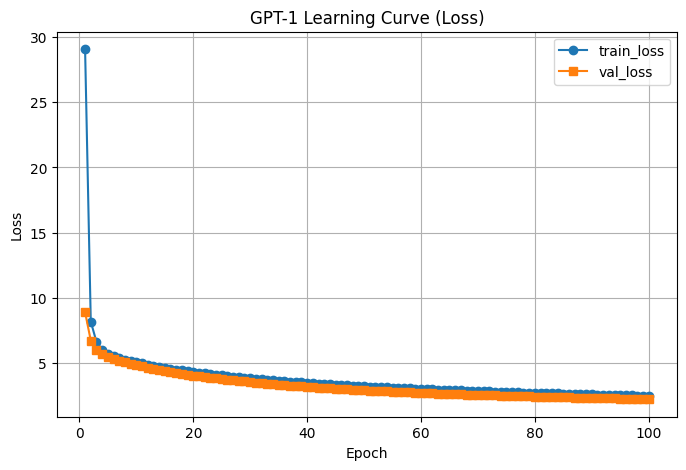

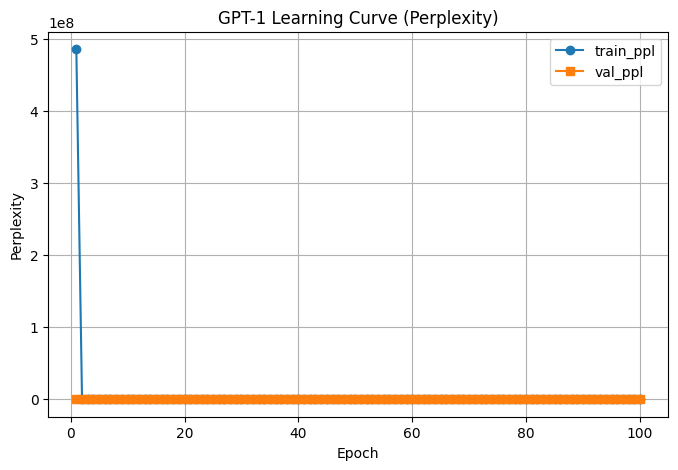

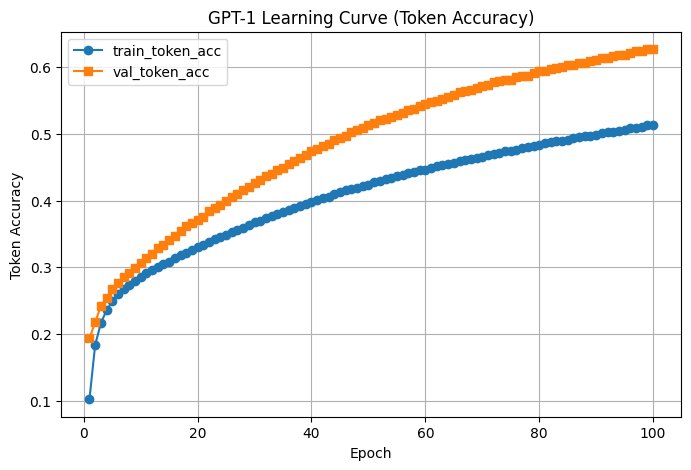

In [68]:
# ============================================================
# [STEP 6 - GPT CELL 4] Visualization: Loss / PPL / Token Acc
# ============================================================

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker='o', label='train_loss')
plt.plot(epochs_range, val_losses, marker='s', label='val_loss')
plt.title("GPT-1 Learning Curve (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_ppls, marker='o', label='train_ppl')
plt.plot(epochs_range, val_ppls, marker='s', label='val_ppl')
plt.title("GPT-1 Learning Curve (Perplexity)")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accs, marker='o', label='train_token_acc')
plt.plot(epochs_range, val_accs, marker='s', label='val_token_acc')
plt.title("GPT-1 Learning Curve (Token Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Token Accuracy")
plt.grid(True)
plt.legend()
plt.show()

In [69]:
# ============================================================
# [STEP 6 - GPT CELL 5] generate() / translate()
# - 입력: <bos> 질문 <sep>
# - 출력: 답변 자동 생성
# - [CHANGED] simple_postprocess()가 이미 있으면 선택적으로 적용 가능
# ============================================================

def _apply_repetition_penalty(logits, generated_ids, penalty=1.2):
    if penalty is None or penalty <= 1.0:
        return logits
    for tid in set(generated_ids):
        logits[tid] /= penalty
    return logits

def _ban_repeat_ngram(logits, generated_ids, n=4):
    if n is None or n <= 1 or len(generated_ids) < (n - 1):
        return logits
    prefix = tuple(generated_ids[-(n - 1):])
    banned = set()
    for i in range(len(generated_ids) - (n - 1)):
        if tuple(generated_ids[i:i + (n - 1)]) == prefix:
            banned.add(generated_ids[i + (n - 1)])
    if banned:
        logits[list(banned)] = -1e9
    return logits

@torch.no_grad()
def generate_from_question(tokens, model, max_new_tokens=30,
                           temperature=0.8, top_k=20,
                           repetition_penalty=1.2,
                           no_repeat_ngram_size=4,
                           min_answer_len=2,
                           apply_postprocess=True):
    """
    tokens: 질문 토큰 list[str]
    입력 형식: <bos> 질문 <sep>
    출력: 생성된 답변 문자열
    """
    model.eval()

    q_ids = encode(tokens)
    context_ids = [BOS_ID] + q_ids + [SEP_ID]

    generated = context_ids[:]

    for _ in range(max_new_tokens):
        input_ids = generated[-(MAX_LEN - 1):]  # pos_len 보호
        x = torch.tensor([input_ids], dtype=torch.long, device=device)

        logits = model(x)               # (1, T, V)
        next_logits = logits[0, -1, :].clone()

        # 너무 빨리 EOS 나오는 것 방지
        answer_part = generated[generated.index(SEP_ID)+1:] if SEP_ID in generated else []
        if len(answer_part) < min_answer_len:
            next_logits[EOS_ID] = -1e9

        next_logits = _apply_repetition_penalty(next_logits, generated, repetition_penalty)
        next_logits = _ban_repeat_ngram(next_logits, generated, no_repeat_ngram_size)

        next_logits = next_logits / max(temperature, 1e-6)

        if top_k is not None and top_k > 0:
            topv, topi = torch.topk(next_logits, k=min(top_k, next_logits.size(-1)))
            probs = F.softmax(topv, dim=-1)
            next_id = topi[torch.multinomial(probs, 1)].item()
        else:
            probs = F.softmax(next_logits, dim=-1)
            next_id = torch.multinomial(probs, 1).item()

        generated.append(next_id)

        if next_id == EOS_ID:
            break

    # <sep> 뒤만 답변으로 추출
    if SEP_ID in generated:
        answer_ids = generated[generated.index(SEP_ID) + 1:]
    else:
        answer_ids = generated[:]

    if EOS_ID in answer_ids:
        answer_ids = answer_ids[:answer_ids.index(EOS_ID)]

    answer_ids = [i for i in answer_ids if i not in (PAD_ID, BOS_ID, EOS_ID, SEP_ID)]
    out_text = sp.decode_ids(answer_ids)

    # [CHANGED] 후처리 함수가 이미 정의되어 있으면 선택적으로 적용
    if apply_postprocess and "simple_postprocess" in globals():
        out_text = simple_postprocess(out_text)

    return out_text

# 기존 함수명도 유지하고 싶다면 alias
def translate(tokens, model, max_len=30):
    return generate_from_question(tokens, model, max_new_tokens=max_len)

In [70]:
# ============================================================
# [STEP 6 - GPT CELL 6] Run examples
# ============================================================

examples = [
    "오늘 너무 기분 좋아",
    "간만에 여자친구랑 데이트 하기로 했어",
    "지루하다 놀러가고 싶어",
    "오늘 일찍 일어났더니 피곤하다",
]

for text in examples:
    q_tokens = text.split()
    out = generate_from_question(q_tokens, model, max_new_tokens=30, apply_postprocess=True)
    print(f"[입력] {text}")
    print(f"[출력] {out}")
    print("-" * 60)

[입력] 오늘 너무 기분 좋아
[출력] 좀 더 도움 이 될 거 예요.
------------------------------------------------------------
[입력] 간만에 여자친구랑 데이트 하기로 했어
[출력] 같이 여행 을 떠나세요.
------------------------------------------------------------
[입력] 지루하다 놀러가고 싶어
[출력] 여행 은 언제나 좋죠.
------------------------------------------------------------
[입력] 오늘 일찍 일어났더니 피곤하다
[출력] 많이 힘들지 않았으면 좋겠어요.
------------------------------------------------------------


### STEP 7-GPT 평가용 간단 지표
- Validation perplexity / token acc 요약
- TEXT BLOCK: Transformer → GPT-1 변경점

In [72]:
# ============================================================
# [STEP 7 - GPT CELL 1] Final test evaluation
# - [CHANGED] 기존 validation 요약 중심에서,
#   최종 평가는 test_dataloader 기준으로 수행
# ============================================================

@torch.no_grad()
def evaluate_loader(dataloader, model):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0

    for inp, tgt in dataloader:
        inp = inp.to(device)
        tgt = tgt.to(device)

        logits = model(inp)
        loss = loss_function(tgt, logits, pad_id=PAD_ID, label_smoothing=0.0)
        acc = token_accuracy(tgt, logits, pad_id=PAD_ID)

        total_loss += float(loss.item())
        total_acc += float(acc)

    avg_loss = total_loss / max(len(dataloader), 1)
    avg_acc = total_acc / max(len(dataloader), 1)
    avg_ppl = math.exp(min(avg_loss, 20))

    return avg_loss, avg_ppl, avg_acc

test_loss, test_ppl, test_acc = evaluate_loader(test_dataloader, model)

print("===== GPT-1 QUEST TEST METRICS =====")
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Perplexity: {test_ppl:.4f}")
print(f"Test Token Acc : {test_acc:.4f}")

===== GPT-1 QUEST TEST METRICS =====
Test Loss      : 2.1746
Test Perplexity: 8.7985
Test Token Acc : 0.6335


In [73]:
# ============================================================
# [STEP 7 - GPT CELL 2] Validation + Test metric summary
# - [CHANGED] val은 학습 선택 기준, test는 최종 보고용으로 함께 제시
# ============================================================

best_val_loss = min(val_losses)
best_val_ppl = min(val_ppls)
best_val_acc = max(val_accs)

print("===== GPT-1 QUEST METRIC SUMMARY =====")
print(f"Best Val Loss       : {best_val_loss:.4f}")
print(f"Best Val Perplexity : {best_val_ppl:.4f}")
print(f"Best Val Token Acc  : {best_val_acc:.4f}")
print("-" * 40)
print(f"Final Test Loss     : {test_loss:.4f}")
print(f"Final Test Perplexity: {test_ppl:.4f}")
print(f"Final Test Token Acc : {test_acc:.4f}")

===== GPT-1 QUEST METRIC SUMMARY =====
Best Val Loss       : 2.2113
Best Val Perplexity : 9.1275
Best Val Token Acc  : 0.6270
----------------------------------------
Final Test Loss     : 2.1746
Final Test Perplexity: 8.7985
Final Test Token Acc : 0.6335


In [74]:
# ============================================================
# [STEP 7 - GPT CELL 3] TEXT BLOCK: Transformer → GPT-1 변경점
# - 제출용 텍스트 블록 출력
# ============================================================

quest_text_block = """
### Transformer 대비 GPT-1 변경점

1. Encoder를 제거하고 Decoder-Only 구조로 변경하였다.
2. Self-Attention은 미래 토큰을 보지 못하도록 Masked Self-Attention만 사용하였다.
3. 기존 seq2seq 구조의 Cross-Attention은 제거하였다.
4. sin/cos positional encoding 대신 learnable positional embedding을 사용하였다.
5. 입력은 질문-답변 쌍을 하나의 연속 토큰 시퀀스(`<bos> 질문 <sep> 답변 <eos>`)로 구성하였다.
6. delimiter token(`<sep>`)도 일반 토큰처럼 임베딩을 학습하도록 구성하였다.
7. 출력은 각 시점의 다음 토큰 logits을 생성하며, 이를 통해 자동 응답 생성이 가능하도록 구현하였다.
8. 학습 중에는 validation set으로 모델을 선택하고, 최종 성능은 test set에서 평가하였다.
"""

print(quest_text_block)


### Transformer 대비 GPT-1 변경점

1. Encoder를 제거하고 Decoder-Only 구조로 변경하였다.
2. Self-Attention은 미래 토큰을 보지 못하도록 Masked Self-Attention만 사용하였다.
3. 기존 seq2seq 구조의 Cross-Attention은 제거하였다.
4. sin/cos positional encoding 대신 learnable positional embedding을 사용하였다.
5. 입력은 질문-답변 쌍을 하나의 연속 토큰 시퀀스(`<bos> 질문 <sep> 답변 <eos>`)로 구성하였다.
6. delimiter token(`<sep>`)도 일반 토큰처럼 임베딩을 학습하도록 구성하였다.
7. 출력은 각 시점의 다음 토큰 logits을 생성하며, 이를 통해 자동 응답 생성이 가능하도록 구현하였다.
8. 학습 중에는 validation set으로 모델을 선택하고, 최종 성능은 test set에서 평가하였다.



### step 8 추가학습
- Stage 2 fine-tuning setup
- Step 8 EarlyStopping
- Additional training loop
- Step 8 전용 러닝커브
- Step 6 + Step 8 합쳐서 시각화
- learning rate 시각화
- 추가학습 후 test 재평가
- 추가학습 전후 성능 비교
- 추가학습 후 생성 예시
- Step 8 요약 텍스트

In [83]:
# ============================================================
# [STEP 8 - GPT CELL 1] Additional training setup
# - 기존 학습된 model은 유지
# - [CHANGED] optimizer는 새로 시작
# - [CHANGED] learning rate를 더 낮춰서 추가학습
# - [CHANGED] cosine decay scheduler 적용
# ============================================================

# 추가학습용 하이퍼파라미터
LR_STAGE8 = 1e-4
EPOCHS_STAGE8 = 100
PATIENCE_STAGE8 = 10
MIN_DELTA_STAGE8 = 1e-4
WEIGHT_DECAY_STAGE8 = WEIGHT_DECAY
MIN_LR_STAGE8 = 1e-5

print("===== STEP 8 SETUP =====")
print("model: keep current best-restored model")
print("new optimizer: YES")
print("LR_STAGE8:", LR_STAGE8)
print("EPOCHS_STAGE8:", EPOCHS_STAGE8)
print("PATIENCE_STAGE8:", PATIENCE_STAGE8)
print("MIN_LR_STAGE8:", MIN_LR_STAGE8)

# [CHANGED] optimizer 새로 생성 (model은 유지)
optimizer_stage8 = torch.optim.AdamW(
    model.parameters(),
    lr=LR_STAGE8,
    weight_decay=WEIGHT_DECAY_STAGE8
)

# [CHANGED] cosine decay scheduler
scheduler_stage8 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_stage8,
    T_max=EPOCHS_STAGE8,
    eta_min=MIN_LR_STAGE8
)

# Step 8 전용 기록 리스트
train_losses_s8 = []
val_losses_s8 = []
train_accs_s8 = []
val_accs_s8 = []
train_ppls_s8 = []
val_ppls_s8 = []
lr_history_s8 = []

print("✅ STEP 8 optimizer/scheduler ready")

===== STEP 8 SETUP =====
model: keep current best-restored model
new optimizer: YES
LR_STAGE8: 0.0001
EPOCHS_STAGE8: 100
PATIENCE_STAGE8: 10
MIN_LR_STAGE8: 1e-05
✅ STEP 8 optimizer/scheduler ready


In [85]:
# ============================================================
# [STEP 8 - GPT CELL 2] EarlyStopping for STEP 8
# - Step 6의 EarlyStopping과 분리
# ============================================================

class EarlyStoppingStage8:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")
        self.bad = 0
        self.best_state = None
        self.best_epoch = None

    def step(self, metric, model, epoch=None):
        improved = (self.best - metric) > self.min_delta
        if improved:
            self.best = metric
            self.bad = 0
            self.best_epoch = epoch
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        else:
            self.bad += 1
            return self.bad >= self.patience

    def restore(self, model, device):
        if self.best_state is not None:
            model.load_state_dict({k: v.to(device) for k, v in self.best_state.items()})

es_stage8 = EarlyStoppingStage8(
    patience=PATIENCE_STAGE8,
    min_delta=MIN_DELTA_STAGE8
)

print("✅ STEP 8 EarlyStopping ready")

✅ STEP 8 EarlyStopping ready


In [87]:
# ============================================================
# [STEP 8 - GPT CELL 3] Additional training loop
# - 기존 model 이어서 추가학습
# - optimizer는 새로 시작
# - train/val metric은 STEP 8 전용 리스트에 저장
# ============================================================

for epoch in range(1, EPOCHS_STAGE8 + 1):
    # ---------------- train ----------------
    model.train()
    total_train_loss = 0.0
    total_train_acc = 0.0

    for inp, tgt in train_dataloader:
        inp = inp.to(device)
        tgt = tgt.to(device)

        optimizer_stage8.zero_grad()

        logits = model(inp)
        loss = loss_function(tgt, logits, pad_id=PAD_ID, label_smoothing=LABEL_SMOOTHING)
        acc = token_accuracy(tgt, logits, pad_id=PAD_ID)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        optimizer_stage8.step()

        total_train_loss += float(loss.item())
        total_train_acc += float(acc)

    avg_train_loss = total_train_loss / max(len(train_dataloader), 1)
    avg_train_acc = total_train_acc / max(len(train_dataloader), 1)
    avg_train_ppl = math.exp(min(avg_train_loss, 20))

    train_losses_s8.append(avg_train_loss)
    train_accs_s8.append(avg_train_acc)
    train_ppls_s8.append(avg_train_ppl)

    # ---------------- validation ----------------
    model.eval()
    total_val_loss = 0.0
    total_val_acc = 0.0

    with torch.no_grad():
        for inp, tgt in val_dataloader:
            inp = inp.to(device)
            tgt = tgt.to(device)

            logits = model(inp)
            loss = loss_function(tgt, logits, pad_id=PAD_ID, label_smoothing=0.0)
            acc = token_accuracy(tgt, logits, pad_id=PAD_ID)

            total_val_loss += float(loss.item())
            total_val_acc += float(acc)

    avg_val_loss = total_val_loss / max(len(val_dataloader), 1)
    avg_val_acc = total_val_acc / max(len(val_dataloader), 1)
    avg_val_ppl = math.exp(min(avg_val_loss, 20))

    val_losses_s8.append(avg_val_loss)
    val_accs_s8.append(avg_val_acc)
    val_ppls_s8.append(avg_val_ppl)

    current_lr = optimizer_stage8.param_groups[0]["lr"]
    lr_history_s8.append(current_lr)

    print(
        f"[STEP8] Epoch {epoch:02d} | "
        f"train_loss={avg_train_loss:.4f} | train_ppl={avg_train_ppl:.2f} | train_acc={avg_train_acc:.4f} || "
        f"val_loss={avg_val_loss:.4f} | val_ppl={avg_val_ppl:.2f} | val_acc={avg_val_acc:.4f} || "
        f"lr={current_lr:.6f}"
    )

    should_stop = es_stage8.step(avg_val_loss, model, epoch=epoch)
    if should_stop:
        print(f"[STEP8] EarlyStopping @ epoch {epoch:02d} | best_val={es_stage8.best:.4f} | best_epoch={es_stage8.best_epoch}")
        break

    scheduler_stage8.step()

# STEP 8 best weight restore
es_stage8.restore(model, device)
print(f"✅ STEP 8 best model restored | best_val={es_stage8.best:.4f} | best_epoch={es_stage8.best_epoch}")

[STEP8] Epoch 01 | train_loss=2.4217 | train_ppl=11.26 | train_acc=0.5225 || val_loss=2.1964 | val_ppl=8.99 | val_acc=0.6336 || lr=0.000100
[STEP8] Epoch 02 | train_loss=2.4015 | train_ppl=11.04 | train_acc=0.5251 || val_loss=2.1831 | val_ppl=8.87 | val_acc=0.6347 || lr=0.000100
[STEP8] Epoch 03 | train_loss=2.3878 | train_ppl=10.89 | train_acc=0.5275 || val_loss=2.1777 | val_ppl=8.83 | val_acc=0.6361 || lr=0.000100
[STEP8] Epoch 04 | train_loss=2.3791 | train_ppl=10.79 | train_acc=0.5284 || val_loss=2.1676 | val_ppl=8.74 | val_acc=0.6392 || lr=0.000100
[STEP8] Epoch 05 | train_loss=2.3666 | train_ppl=10.66 | train_acc=0.5302 || val_loss=2.1668 | val_ppl=8.73 | val_acc=0.6401 || lr=0.000100
[STEP8] Epoch 06 | train_loss=2.3580 | train_ppl=10.57 | train_acc=0.5329 || val_loss=2.1577 | val_ppl=8.65 | val_acc=0.6409 || lr=0.000099
[STEP8] Epoch 07 | train_loss=2.3515 | train_ppl=10.50 | train_acc=0.5330 || val_loss=2.1514 | val_ppl=8.60 | val_acc=0.6431 || lr=0.000099
[STEP8] Epoch 08 | t

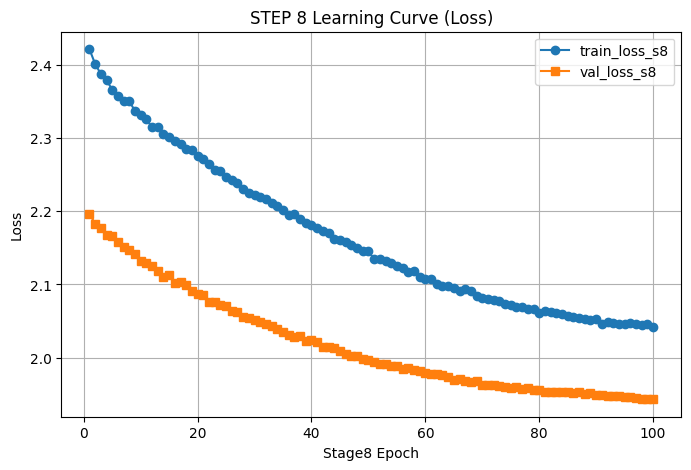

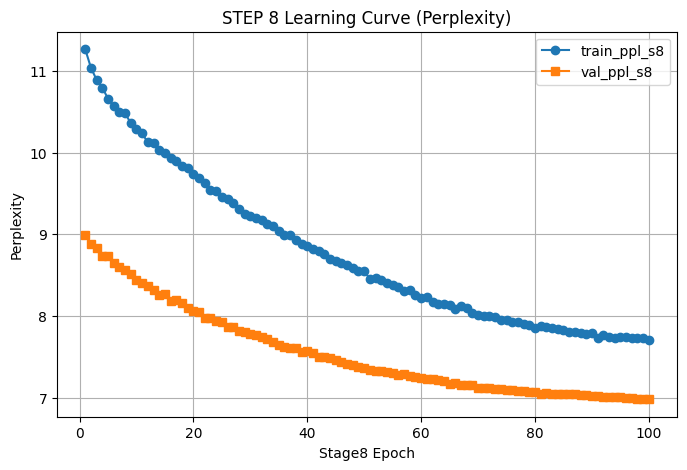

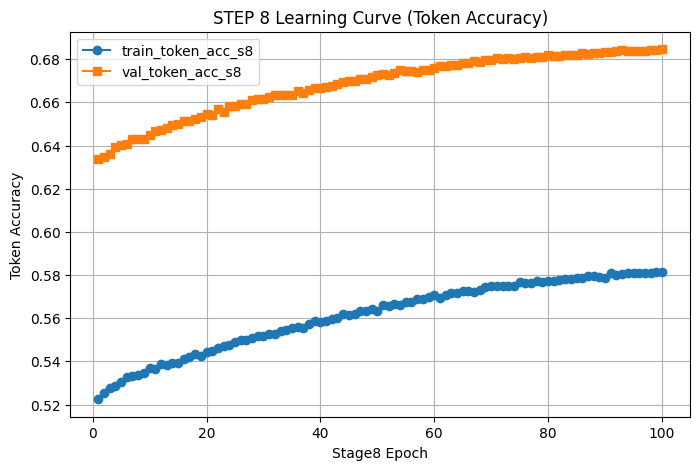

In [88]:
# ============================================================
# [STEP 8 - GPT CELL 4] STEP 8 only visualization
# - Step 8에서 새롭게 나온 train/val loss, ppl, acc만 따로 시각화
# ============================================================

epochs_range_s8 = range(1, len(train_losses_s8) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range_s8, train_losses_s8, marker='o', label='train_loss_s8')
plt.plot(epochs_range_s8, val_losses_s8, marker='s', label='val_loss_s8')
plt.title("STEP 8 Learning Curve (Loss)")
plt.xlabel("Stage8 Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range_s8, train_ppls_s8, marker='o', label='train_ppl_s8')
plt.plot(epochs_range_s8, val_ppls_s8, marker='s', label='val_ppl_s8')
plt.title("STEP 8 Learning Curve (Perplexity)")
plt.xlabel("Stage8 Epoch")
plt.ylabel("Perplexity")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range_s8, train_accs_s8, marker='o', label='train_token_acc_s8')
plt.plot(epochs_range_s8, val_accs_s8, marker='s', label='val_token_acc_s8')
plt.title("STEP 8 Learning Curve (Token Accuracy)")
plt.xlabel("Stage8 Epoch")
plt.ylabel("Token Accuracy")
plt.grid(True)
plt.legend()
plt.show()

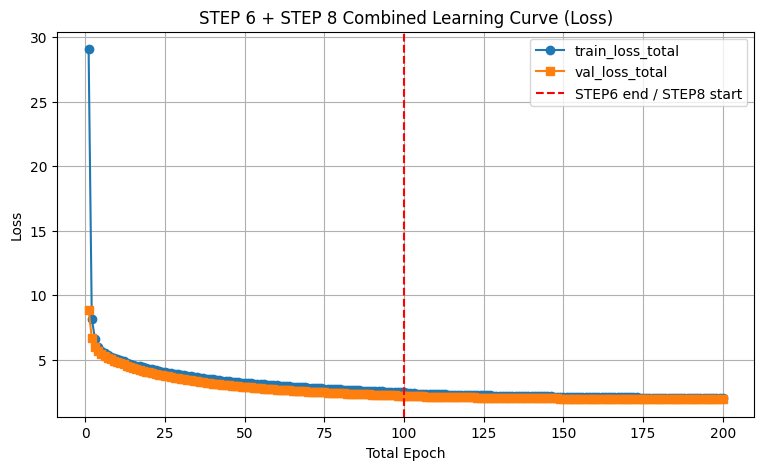

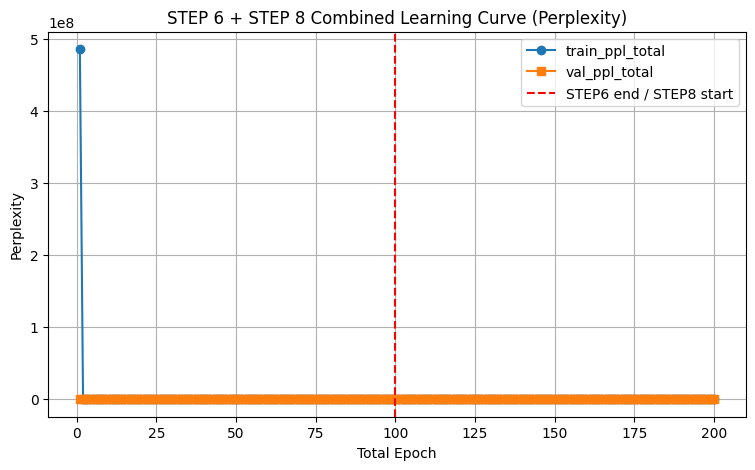

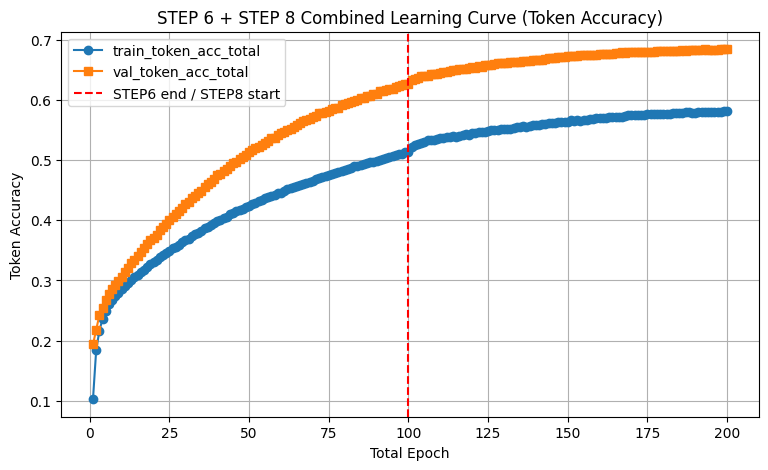

In [89]:
# ============================================================
# [STEP 8 - GPT CELL 5] Combined visualization: STEP 6 + STEP 8
# - 기존 학습 기록(train_losses, val_losses 등)과
#   추가학습 기록(train_losses_s8, val_losses_s8 등)을 이어붙여 시각화
# ============================================================

combined_train_losses = train_losses + train_losses_s8
combined_val_losses   = val_losses + val_losses_s8

combined_train_ppls = train_ppls + train_ppls_s8
combined_val_ppls   = val_ppls + val_ppls_s8

combined_train_accs = train_accs + train_accs_s8
combined_val_accs   = val_accs + val_accs_s8

epochs_range_combined = range(1, len(combined_train_losses) + 1)
step6_end_epoch = len(train_losses)

plt.figure(figsize=(9, 5))
plt.plot(epochs_range_combined, combined_train_losses, marker='o', label='train_loss_total')
plt.plot(epochs_range_combined, combined_val_losses, marker='s', label='val_loss_total')
plt.axvline(step6_end_epoch, color='red', linestyle='--', label='STEP6 end / STEP8 start')
plt.title("STEP 6 + STEP 8 Combined Learning Curve (Loss)")
plt.xlabel("Total Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epochs_range_combined, combined_train_ppls, marker='o', label='train_ppl_total')
plt.plot(epochs_range_combined, combined_val_ppls, marker='s', label='val_ppl_total')
plt.axvline(step6_end_epoch, color='red', linestyle='--', label='STEP6 end / STEP8 start')
plt.title("STEP 6 + STEP 8 Combined Learning Curve (Perplexity)")
plt.xlabel("Total Epoch")
plt.ylabel("Perplexity")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epochs_range_combined, combined_train_accs, marker='o', label='train_token_acc_total')
plt.plot(epochs_range_combined, combined_val_accs, marker='s', label='val_token_acc_total')
plt.axvline(step6_end_epoch, color='red', linestyle='--', label='STEP6 end / STEP8 start')
plt.title("STEP 6 + STEP 8 Combined Learning Curve (Token Accuracy)")
plt.xlabel("Total Epoch")
plt.ylabel("Token Accuracy")
plt.grid(True)
plt.legend()
plt.show()

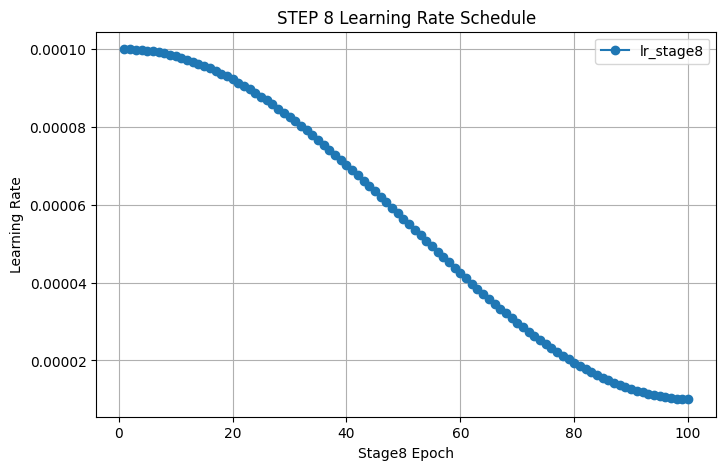

In [90]:
# ============================================================
# [STEP 8 - GPT CELL 6] STEP 8 LR visualization
# - 새 optimizer + cosine decay가 실제로 어떻게 변했는지 확인
# ============================================================

epochs_lr_s8 = range(1, len(lr_history_s8) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_lr_s8, lr_history_s8, marker='o', label='lr_stage8')
plt.title("STEP 8 Learning Rate Schedule")
plt.xlabel("Stage8 Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.legend()
plt.show()

In [91]:
# ============================================================
# [STEP 8 - GPT CELL 7] Final test evaluation after STEP 8
# - Step 7의 evaluate_loader를 그대로 사용
# - 추가학습 후 성능이 얼마나 변했는지 확인
# ============================================================

# Step 7에서 evaluate_loader가 이미 정의되어 있다고 가정
test_loss_s8, test_ppl_s8, test_acc_s8 = evaluate_loader(test_dataloader, model)

print("===== GPT-1 STEP 8 TEST METRICS =====")
print(f"Test Loss (STEP8)      : {test_loss_s8:.4f}")
print(f"Test Perplexity (STEP8): {test_ppl_s8:.4f}")
print(f"Test Token Acc (STEP8) : {test_acc_s8:.4f}")

===== GPT-1 STEP 8 TEST METRICS =====
Test Loss (STEP8)      : 1.9145
Test Perplexity (STEP8): 6.7833
Test Token Acc (STEP8) : 0.6919


In [92]:
# ============================================================
# [STEP 8 - GPT CELL 8] Compare STEP 7 vs STEP 8
# - Step 7 최종 test 성능과 Step 8 추가학습 후 성능 비교
# ============================================================

print("===== STEP 7 vs STEP 8 TEST COMPARISON =====")
print(f"[STEP7] Test Loss       : {test_loss:.4f}")
print(f"[STEP7] Test Perplexity : {test_ppl:.4f}")
print(f"[STEP7] Test Token Acc  : {test_acc:.4f}")
print("-" * 45)
print(f"[STEP8] Test Loss       : {test_loss_s8:.4f}")
print(f"[STEP8] Test Perplexity : {test_ppl_s8:.4f}")
print(f"[STEP8] Test Token Acc  : {test_acc_s8:.4f}")
print("-" * 45)

print("===== DELTA (STEP8 - STEP7) =====")
print(f"Δ Loss       : {test_loss_s8 - test_loss:+.4f}")
print(f"Δ Perplexity : {test_ppl_s8 - test_ppl:+.4f}")
print(f"Δ Token Acc  : {test_acc_s8 - test_acc:+.4f}")

===== STEP 7 vs STEP 8 TEST COMPARISON =====
[STEP7] Test Loss       : 2.1746
[STEP7] Test Perplexity : 8.7985
[STEP7] Test Token Acc  : 0.6335
---------------------------------------------
[STEP8] Test Loss       : 1.9145
[STEP8] Test Perplexity : 6.7833
[STEP8] Test Token Acc  : 0.6919
---------------------------------------------
===== DELTA (STEP8 - STEP7) =====
Δ Loss       : -0.2601
Δ Perplexity : -2.0152
Δ Token Acc  : +0.0584


In [93]:
# ============================================================
# [STEP 8 - GPT CELL 9] Generation examples after STEP 8
# - Step 6 CELL 6과 같은 예시를 다시 출력
# - 추가학습 후 응답이 어떻게 바뀌었는지 비교 가능
# ============================================================

examples_stage8 = [
    "오늘 너무 기분 좋아",
    "간만에 여자친구랑 데이트 하기로 했어",
    "지루하다 놀러가고 싶어",
    "오늘 일찍 일어났더니 피곤하다",
]

for text in examples_stage8:
    q_tokens = text.split()
    out = generate_from_question(q_tokens, model, max_new_tokens=30, apply_postprocess=True)
    print(f"[입력] {text}")
    print(f"[STEP8 출력] {out}")
    print("-" * 60)

[입력] 오늘 너무 기분 좋아
[STEP8 출력] 힘 을 내세 요.
------------------------------------------------------------
[입력] 간만에 여자친구랑 데이트 하기로 했어
[STEP8 출력] 새로운 여행 을 떠나 보세요.
------------------------------------------------------------
[입력] 지루하다 놀러가고 싶어
[STEP8 출력] 세상 은 넓고 특징 이에요.
------------------------------------------------------------
[입력] 오늘 일찍 일어났더니 피곤하다
[STEP8 출력] 좋은 곳 으로 가세 요.
------------------------------------------------------------


In [94]:
# ============================================================
# [STEP 8 - GPT CELL 10] STEP 8 summary text
# - 보고서/마크다운용 요약
# ============================================================

step8_summary = f"""
### STEP 8 추가학습 요약

1. Step 6에서 validation 기준 best model을 복원한 뒤 추가학습을 수행하였다.
2. model 파라미터는 유지하고, optimizer는 새로 초기화하여 후반 미세조정 형태로 진행하였다.
3. 추가학습에서는 더 낮은 learning rate({LR_STAGE8})를 사용하고 cosine decay를 적용하였다.
4. Step 8의 train/validation loss, perplexity, token-level accuracy를 별도로 기록하였다.
5. 또한 Step 6과 Step 8의 학습 곡선을 이어붙여 전체 학습 흐름을 함께 시각화하였다.
6. 최종 성능은 test dataset에서 다시 평가하였다.
"""

print(step8_summary)


### STEP 8 추가학습 요약

1. Step 6에서 validation 기준 best model을 복원한 뒤 추가학습을 수행하였다.
2. model 파라미터는 유지하고, optimizer는 새로 초기화하여 후반 미세조정 형태로 진행하였다.
3. 추가학습에서는 더 낮은 learning rate(0.0001)를 사용하고 cosine decay를 적용하였다.
4. Step 8의 train/validation loss, perplexity, token-level accuracy를 별도로 기록하였다.
5. 또한 Step 6과 Step 8의 학습 곡선을 이어붙여 전체 학습 흐름을 함께 시각화하였다.
6. 최종 성능은 test dataset에서 다시 평가하였다.

